# 1. Setup the Environment

This notebook trains the **final custom CNN** for real-vs-AI image classification.

**Where we stand before this notebook:** earlier experiments identified the strongest parameter set. Those experiments have been removed to reduce runtime and make the final notebook easier to rerun.

**What this notebook does:** it loads the same dataset, applies the standardized neural-image preprocessing pipeline, trains one final Custom CNN model, evaluates it with the same reports used across all notebooks, and saves the outputs.


In [1]:
!pip -q install datasets huggingface_hub pillow matplotlib pandas scikit-learn
!pip -q install lightning torchvision


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 54.8 MB/s eta 0:00:00


In [2]:
import os
import random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import lightning as L
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint, Callback
from datasets import load_dataset, concatenate_datasets, Features, Image as HFImage, Value
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support, precision_score, recall_score, roc_auc_score, roc_curve
from IPython.display import display


# 2. Define Notebook-Wide Settings

**Where we stand:** the packages are available, but the final model settings have not been defined.

**What this section does:** it fixes the seed and stores the selected final parameters. The shared decision threshold is `0.35`. Since class `1` means AI-generated, this lower threshold makes the model more conservative about predicting `Real`.


In [3]:
SEED = 42
NUM_WORKERS = 2
seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

FINAL_MODEL_NAME = "final_custom_cnn_baseline"
FINAL_MAX_EPOCHS = 15
FINAL_LEARNING_RATE = 1e-3
FINAL_WEIGHT_DECAY = 1e-4
FINAL_THRESHOLD = 0.35
FINAL_BATCH_SIZE = 32
USE_WEIGHTED_SAMPLER = True
FINAL_CONV_CHANNELS = (32, 64, 128)
FINAL_DENSE_UNITS = 128
FINAL_DROPOUT_RATE = 0.30

RESULTS_DIR = "results"
CHECKPOINT_DIR = "checkpoints"
MODEL_DIR = "models"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("Final model:", FINAL_MODEL_NAME)
print("Max epochs:", FINAL_MAX_EPOCHS)
print("Learning rate:", FINAL_LEARNING_RATE)
print("Weight decay:", FINAL_WEIGHT_DECAY)
print("Decision threshold:", FINAL_THRESHOLD)
print("Weighted sampler:", USE_WEIGHTED_SAMPLER)


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Final model: final_custom_cnn_baseline
Max epochs: 15
Learning rate: 0.001
Weight decay: 0.0001
Decision threshold: 0.35
Weighted sampler: True


# 3. Load and Prepare the Dataset

**Where we stand:** the notebook is configured, but no image data has been loaded yet.

**What this section does:** it loads the main Defactify dataset, adds the extra real-image dataset used in the project, and keeps the same train/validation/test split structure used across the notebooks.


In [4]:
from huggingface_hub import login
login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
dataset = load_dataset("Rajarshi-Roy-research/Defactify_Image_Dataset")
extra_dataset = load_dataset("Parveshiiii/AI-vs-Real",verification_mode="no_checks")

print(dataset)
print(extra_dataset)


README.md: 0.00B [00:00, ?B/s]

data/validation-00000-of-00002.parquet:   0%|          | 0.00/333M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

data/train-00002-of-00005.parquet:   0%|          | 0.00/826M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/805M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 9000
    })
    train: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 42000
    })
    test: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 45000
    })
})
DatasetDict({
    train: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 13999
    })
})


In [6]:
def prepare_extra_real_images(extra_dataset):
    # Convert the auxiliary real-image dataset to the same schema as the main dataset.
    real_images_only = extra_dataset["train"].filter(lambda x: x["binary_label"] == 1)

    def convert_example(example):
        return {
            "Image": example["image"],
            "Label_A": np.int32(0),
            "Label_B": np.int32(0),
        }

    real_images_converted = real_images_only.map(
        convert_example,
        remove_columns=real_images_only.column_names,
    )

    target_features = Features({
        "Image": HFImage(),
        "Label_A": Value("int32"),
        "Label_B": Value("int32"),
    })

    return real_images_converted.cast(target_features)


extra_real_images = prepare_extra_real_images(extra_dataset)
dataset["train"] = concatenate_datasets([dataset["train"], extra_real_images])

print("New training size after adding extra real images:", len(dataset["train"]))


Filter:   0%|          | 0/13999 [00:00<?, ? examples/s]

Map:   0%|          | 0/10666 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/10666 [00:00<?, ? examples/s]

New training size after adding extra real images: 52666


**Where this leaves us:** the dataset is loaded and the training split contains the additional real images. The next section checks the class balance so the final metrics can be interpreted correctly.


# 4. Inspect Class Balance

**Where we stand:** the dataset is ready, but we need to confirm the binary labels and generator labels.

**What this section does:** it prints the class distribution for `Label_A` and `Label_B` in each split. `Label_A` is used for binary classification, while `Label_B` is used later for per-generator analysis.


In [7]:
LABEL_A_NAMES = {0: "Real", 1: "AI-generated"}
LABEL_B_NAMES = {0: "Real", 1: "SD21", 2: "SDXL", 3: "SD3", 4: "DALLE3", 5: "Midjourney"}


def split_distribution_table(dataset):
    rows = []
    for split_name in ["train", "validation", "test"]:
        split = dataset[split_name]
        for label_id, count in sorted(Counter(split["Label_A"]).items()):
            rows.append({"split": split_name, "label_type": "Label_A", "label_id": label_id, "label_name": LABEL_A_NAMES.get(label_id, str(label_id)), "count": count})
        for label_id, count in sorted(Counter(split["Label_B"]).items()):
            rows.append({"split": split_name, "label_type": "Label_B", "label_id": label_id, "label_name": LABEL_B_NAMES.get(label_id, str(label_id)), "count": count})
    return pd.DataFrame(rows)


distribution_df = split_distribution_table(dataset)
display(distribution_df)


,split,label_type,label_id,label_name,count
0,train,Label_A,0,Real,17666
1,train,Label_A,1,AI-generated,35000
2,train,Label_B,0,Real,17666
3,train,Label_B,1,SD21,7000
4,train,Label_B,2,SDXL,7000
5,train,Label_B,3,SD3,7000
6,train,Label_B,4,DALLE3,7000
7,train,Label_B,5,Midjourney,7000
8,validation,Label_A,0,Real,1500
9,validation,Label_A,1,AI-generated,7500


# 5. Define Image Preprocessing and DataLoaders

**Where we stand:** the dataset is loaded, but images are still in Hugging Face format.

**What this section does:** it defines deterministic evaluation preprocessing and augmented training preprocessing, wraps the Hugging Face dataset for PyTorch, and creates train/validation/test DataLoaders. The training loader uses a weighted sampler because the binary dataset is imbalanced. Validation and test data are never shuffled and never augmented.


In [8]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


In [9]:
class HuggingFaceImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = example["Image"]
        label = int(example["Label_A"])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_weighted_sampler(hf_split):
    labels = [int(x) for x in hf_split["Label_A"]]
    class_counts = Counter(labels)
    class_weights = {label: 1.0 / count for label, count in class_counts.items()}
    sample_weights = torch.DoubleTensor([class_weights[label] for label in labels])
    return WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)


train_dataset = HuggingFaceImageDataset(dataset["train"], transform=train_transform)
val_dataset = HuggingFaceImageDataset(dataset["validation"], transform=eval_transform)
test_dataset = HuggingFaceImageDataset(dataset["test"], transform=eval_transform)
train_sampler = build_weighted_sampler(dataset["train"]) if USE_WEIGHTED_SAMPLER else None

train_loader = DataLoader(train_dataset, batch_size=FINAL_BATCH_SIZE, sampler=train_sampler, shuffle=False if USE_WEIGHTED_SAMPLER else True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=FINAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=FINAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train images: 52666
Validation images: 9000
Test images: 45000
Train batches: 1646
Validation batches: 282
Test batches: 1407


# 6. Define the Final Custom CNN Model

**Where we stand:** the data pipeline is ready.

**What this section does:** it defines the selected final model architecture only. Older experiment variants have been removed so the notebook trains one model with one parameter set.


In [10]:
class CustomCNNLightning(L.LightningModule):
    def __init__(self, lr=1e-3, weight_decay=1e-4, threshold=0.35, conv_channels=(32, 64, 128), dense_units=128, dropout_rate=0.3):
        super().__init__()
        self.save_hyperparameters()
        conv_layers = []
        in_channels = 3
        for out_channels in conv_channels:
            conv_layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            ])
            in_channels = out_channels
        self.feature_extractor = nn.Sequential(*conv_layers)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(conv_channels[-1], dense_units), nn.ReLU(inplace=True), nn.Dropout(dropout_rate), nn.Linear(dense_units, 1))
        self.loss_fn = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.classifier(self.global_pool(self.feature_extractor(x)))

    def _shared_step(self, batch, stage):
        images, labels = batch
        labels = labels.float().unsqueeze(1)
        logits = self(images)
        loss = self.loss_fn(logits, labels)
        probs = torch.sigmoid(logits)
        preds = (probs >= self.hparams.threshold).float()
        acc = (preds == labels).float().mean()
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True)
        self.log(f"{stage}_acc", acc, prog_bar=True, on_epoch=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        self._shared_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}


# 7. Define Training and Evaluation Helpers

**Where we stand:** the model class exists, but we still need reusable helpers for checkpointing, learning curves, predictions, and standardized reports.

**What this section does:** it creates the same metric/reporting functions used across the neural notebooks, including precision and recall in the summary statistics.


In [11]:
class HistoryCallback(Callback):
    def __init__(self):
        super().__init__()
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if "train_loss" in metrics:
            self.train_loss.append(float(metrics["train_loss"].detach().cpu()))
        if "train_acc" in metrics:
            self.train_acc.append(float(metrics["train_acc"].detach().cpu()))
        if "val_loss" in metrics:
            self.val_loss.append(float(metrics["val_loss"].detach().cpu()))
        if "val_acc" in metrics:
            self.val_acc.append(float(metrics["val_acc"].detach().cpu()))


def plot_training_curves(history_callback, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history_callback.train_loss, label="Train Loss")
    plt.plot(history_callback.val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_callback.train_acc, label="Train Accuracy")
    plt.plot(history_callback.val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} — Accuracy")
    plt.legend()
    plt.show()


def collect_predictions(model, dataloader, threshold=None):
    threshold = model.hparams.threshold if threshold is None else threshold
    model.eval()
    model.freeze()
    device = next(model.parameters()).device
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits).squeeze(1)
            preds = (probs >= threshold).int()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels, dtype=np.int32), np.array(all_preds, dtype=np.int32), np.array(all_probs, dtype=np.float32)


In [12]:
def make_classification_report_df(y_true, y_pred):
    report = classification_report(y_true, y_pred, target_names=["Real", "AI-generated"], output_dict=True, zero_division=0)
    return pd.DataFrame([
        {"Class / Metric": "Real", "Precision": report["Real"]["precision"], "Recall": report["Real"]["recall"], "F1-score": report["Real"]["f1-score"], "Support": int(report["Real"]["support"])},
        {"Class / Metric": "AI-generated", "Precision": report["AI-generated"]["precision"], "Recall": report["AI-generated"]["recall"], "F1-score": report["AI-generated"]["f1-score"], "Support": int(report["AI-generated"]["support"])},
        {"Class / Metric": "Accuracy", "Precision": np.nan, "Recall": np.nan, "F1-score": report["accuracy"], "Support": len(y_true)},
        {"Class / Metric": "Macro average", "Precision": report["macro avg"]["precision"], "Recall": report["macro avg"]["recall"], "F1-score": report["macro avg"]["f1-score"], "Support": int(report["macro avg"]["support"])},
        {"Class / Metric": "Weighted average", "Precision": report["weighted avg"]["precision"], "Recall": report["weighted avg"]["recall"], "F1-score": report["weighted avg"]["f1-score"], "Support": int(report["weighted avg"]["support"])},
    ])


def make_summary_stats_df(model_name, y_true, y_pred, y_prob, threshold):
    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    return pd.DataFrame([{
        "model_name": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_real": p[0], "recall_real": r[0], "f1_real": f1[0],
        "precision_ai": p[1], "recall_ai": r[1], "f1_ai": f1[1],
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "support_real": int(support[0]),
        "support_ai": int(support[1]),
    }])


def plot_confusion_matrix_df(cm_df, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_df.values)
    ax.set_xticks(range(len(cm_df.columns)))
    ax.set_yticks(range(len(cm_df.index)))
    ax.set_xticklabels(cm_df.columns)
    ax.set_yticklabels(cm_df.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            value = cm_df.iloc[i, j]
            text = f"{value:.2f}" if isinstance(value, float) else str(value)
            ax.text(j, i, text, ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def make_per_generator_df(test_split, y_pred, y_prob):
    label_b = np.array(test_split["Label_B"], dtype=np.int32)
    rows = []
    for label_id in sorted(set(label_b)):
        if label_id == 0:
            continue
        mask = label_b == label_id
        group_preds = y_pred[mask]
        group_probs = y_prob[mask]
        rows.append({
            "AI Generator": LABEL_B_NAMES.get(label_id, f"Label_B {label_id}"),
            "Test Images": int(mask.sum()),
            "Correctly Predicted AI": int((group_preds == 1).sum()),
            "Missed as Real": int((group_preds == 0).sum()),
            "AI Recall": float((group_preds == 1).mean()),
            "Mean Predicted AI Probability": float(group_probs.mean()),
            "Median Predicted AI Probability": float(np.median(group_probs)),
        })
    return pd.DataFrame(rows).sort_values("AI Recall", ascending=False).reset_index(drop=True)


def make_probability_summary_df(y_true, y_prob):
    rows = []
    for label_id, label_name in LABEL_A_NAMES.items():
        mask = y_true == label_id
        rows.append({
            "True Class": label_name,
            "Images": int(mask.sum()),
            "Mean Predicted AI Probability": float(y_prob[mask].mean()),
            "Median Predicted AI Probability": float(np.median(y_prob[mask])),
            "Min Predicted AI Probability": float(y_prob[mask].min()),
            "Max Predicted AI Probability": float(y_prob[mask].max()),
        })
    return pd.DataFrame(rows)


def evaluate_final_model(model, dataloader, hf_test_split, model_name, threshold):
    y_true, y_pred, y_prob = collect_predictions(model, dataloader, threshold=threshold)
    classification_report_df = make_classification_report_df(y_true, y_pred)
    summary_stats_df = make_summary_stats_df(model_name, y_true, y_pred, y_prob, threshold)
    per_generator_df = make_per_generator_df(hf_test_split, y_pred, y_prob)
    probability_summary_df = make_probability_summary_df(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    confusion_matrix_df = pd.DataFrame(cm, index=["Real", "AI-generated"], columns=["Predicted Real", "Predicted AI-generated"])
    normalized_cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    normalized_confusion_matrix_df = pd.DataFrame(normalized_cm, index=["Real", "AI-generated"], columns=["Predicted Real", "Predicted AI-generated"])

    print("Classification report")
    display(classification_report_df)
    print("Summary statistics")
    display(summary_stats_df)
    print("Confusion matrix")
    display(confusion_matrix_df)
    plot_confusion_matrix_df(confusion_matrix_df, f"{model_name} Confusion Matrix")
    print("Normalized confusion matrix")
    display(normalized_confusion_matrix_df)
    plot_confusion_matrix_df(normalized_confusion_matrix_df, f"{model_name} Normalized Confusion Matrix")
    print("Per-generator AI performance")
    display(per_generator_df)
    print("Probability summary by true class")
    display(probability_summary_df)

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.hist(y_prob[y_true == 0], bins=30, alpha=0.6, label="Real")
    plt.hist(y_prob[y_true == 1], bins=30, alpha=0.6, label="AI-generated")
    plt.axvline(threshold, linestyle="--", label=f"Threshold = {threshold}")
    plt.xlabel("Predicted AI Probability")
    plt.ylabel("Number of Images")
    plt.title(f"{model_name} Predicted AI Probability Distribution")
    plt.legend()
    plt.show()

    predictions_df = pd.DataFrame({
        "true_label": y_true,
        "true_label_name": [LABEL_A_NAMES[int(x)] for x in y_true],
        "predicted_label": y_pred,
        "predicted_label_name": [LABEL_A_NAMES[int(x)] for x in y_pred],
        "predicted_ai_probability": y_prob,
        "threshold": threshold,
        "label_b": np.array(hf_test_split["Label_B"], dtype=np.int32),
        "label_b_name": [LABEL_B_NAMES[int(x)] for x in hf_test_split["Label_B"]],
    })

    return {
        "classification_report_df": classification_report_df,
        "summary_stats_df": summary_stats_df,
        "per_generator_df": per_generator_df,
        "probability_summary_df": probability_summary_df,
        "confusion_matrix_df": confusion_matrix_df,
        "normalized_confusion_matrix_df": normalized_confusion_matrix_df,
        "predictions_df": predictions_df,
    }


# 8. Create the Final Model and Trainer

**Where we stand:** the final model class and helper functions are ready.

**What this section does:** it creates one model, one checkpoint callback, one history callback, and one Lightning trainer. There is no experiment loop.


In [13]:
history_callback = HistoryCallback()
checkpoint_callback = ModelCheckpoint(dirpath=CHECKPOINT_DIR, filename=FINAL_MODEL_NAME, save_top_k=1, monitor="val_loss", mode="min")

model = CustomCNNLightning(lr=FINAL_LEARNING_RATE, weight_decay=FINAL_WEIGHT_DECAY, threshold=FINAL_THRESHOLD, conv_channels=FINAL_CONV_CHANNELS, dense_units=FINAL_DENSE_UNITS, dropout_rate=FINAL_DROPOUT_RATE)

trainer = Trainer(max_epochs=FINAL_MAX_EPOCHS, accelerator="auto", devices=1, callbacks=[history_callback, checkpoint_callback], log_every_n_steps=50)
print(model)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


CustomCNNLightning(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=

# 9. Train the Final Model

**Where we stand:** the trainer and model have been created.

**What this section does:** it trains the final selected model for 15 epochs and saves the checkpoint with the lowest validation loss.


In [14]:
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("Best validation checkpoint:", checkpoint_callback.best_model_path)


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name              ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ feature_extractor │ Sequential        │ 93.7 K │ train │     0 │
│ 1 │ global_pool       │ AdaptiveAvgPool2d │      0 │ train │     0 │
│ 2 │ classifier        │ Sequential        │ 16.6 K │ train │     0 │
│ 3 │ loss_fn           │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 110 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 110 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


Best validation checkpoint: /content/checkpoints/final_custom_cnn_baseline.ckpt


# 10. Plot Training Curves

**Where we stand:** training is complete.

**What this section does:** it plots training and validation loss and accuracy using the same format as the other neural notebooks.


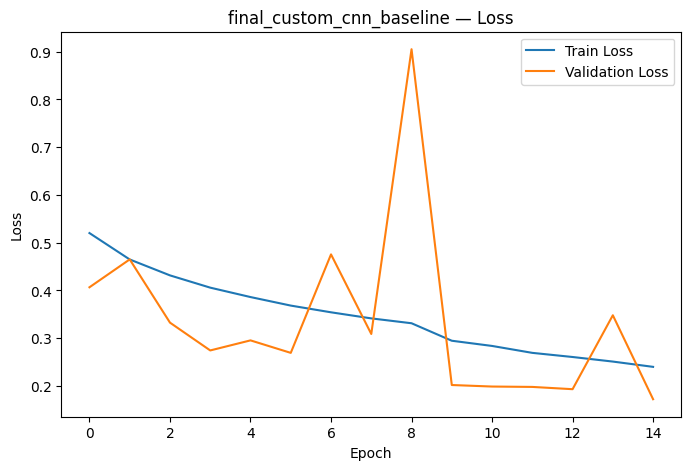

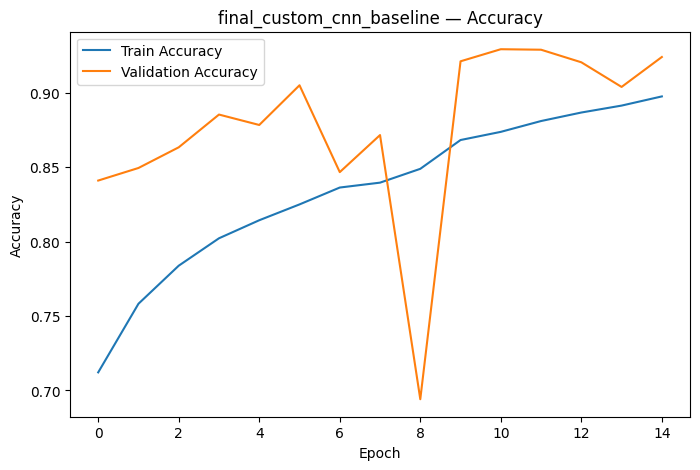

In [15]:
plot_training_curves(history_callback, FINAL_MODEL_NAME)


# 11. Reload the Best Checkpoint

**Where we stand:** the final epoch is not necessarily the best model.

**What this section does:** it reloads the checkpoint with the lowest validation loss before running test evaluation.


In [16]:
best_model = CustomCNNLightning.load_from_checkpoint(checkpoint_callback.best_model_path)
print("Best checkpoint path:", checkpoint_callback.best_model_path)


Best checkpoint path: /content/checkpoints/final_custom_cnn_baseline.ckpt


# 12. Evaluate the Final Model on the Test Set

**Where we stand:** the best validation checkpoint has been reloaded.

**What this section does:** it evaluates the model on the untouched test set and creates the standardized outputs: classification report, summary statistics with precision and recall, confusion matrices, per-generator analysis, probability summary, ROC curve, and probability histogram.


Classification report


,Class / Metric,Precision,Recall,F1-score,Support
0,Real,0.581107,0.713600,0.640575,7500
1,AI-generated,0.939983,0.897120,0.918052,37500
2,Accuracy,NaN,NaN,0.866533,45000
3,Macro average,0.760545,0.805360,0.779313,45000
4,Weighted average,0.880171,0.866533,0.871805,45000


Summary statistics


,model_name,threshold,accuracy,precision_real,recall_real,f1_real,precision_ai,recall_ai,f1_ai,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,roc_auc,support_real,support_ai
0,final_custom_cnn_baseline,0.35,0.866533,0.581107,0.7136,0.640575,0.939983,0.89712,0.918052,0.760545,0.80536,0.779313,0.880171,0.866533,0.871805,0.918058,7500,37500


Confusion matrix


,Predicted Real,Predicted AI-generated
Real,5352,2148
AI-generated,3858,33642


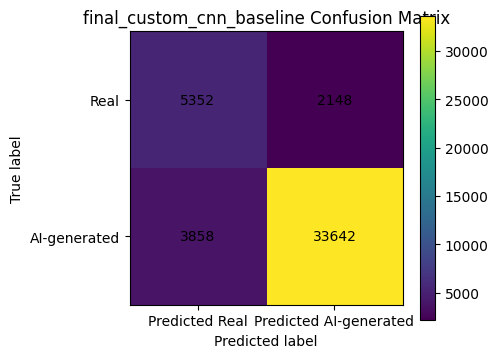

Normalized confusion matrix


,Predicted Real,Predicted AI-generated
Real,0.71360,0.28640
AI-generated,0.10288,0.89712


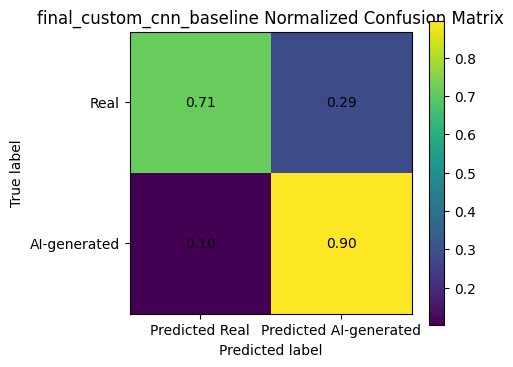

Per-generator AI performance


,AI Generator,Test Images,Correctly Predicted AI,Missed as Real,AI Recall,Mean Predicted AI Probability,Median Predicted AI Probability
0,DALLE3,7500,7119,381,0.949200,0.908128,0.997200
1,Midjourney,7500,6734,766,0.897867,0.846018,0.985960
2,SD3,7500,6702,798,0.893600,0.810618,0.946846
3,SDXL,7500,6609,891,0.881200,0.841001,0.984809
4,SD21,7500,6478,1022,0.863733,0.798277,0.955149


Probability summary by true class


,True Class,Images,Mean Predicted AI Probability,Median Predicted AI Probability,Min Predicted AI Probability,Max Predicted AI Probability
0,Real,7500,0.253617,0.102727,0.000009,0.998519
1,AI-generated,37500,0.840808,0.979740,0.000015,1.000000


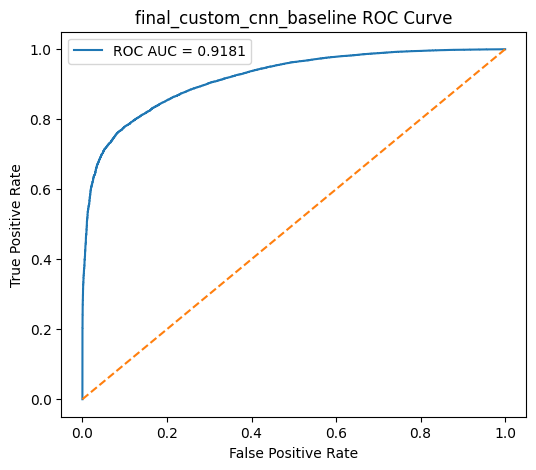

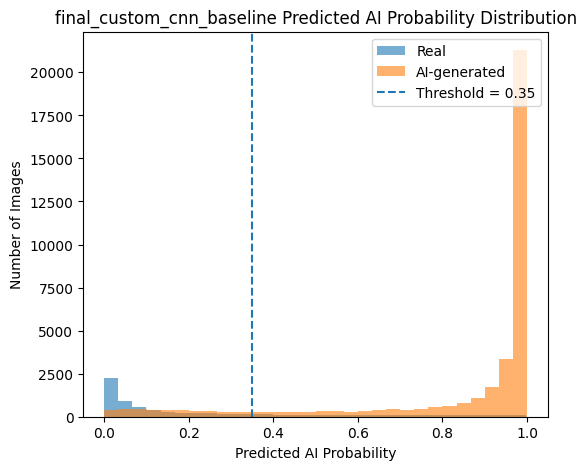

In [17]:
evaluation_outputs = evaluate_final_model(model=best_model, dataloader=test_loader, hf_test_split=dataset["test"], model_name=FINAL_MODEL_NAME, threshold=FINAL_THRESHOLD)


# 13. Save Model and Results

**Where we stand:** the final model has been evaluated.

**What this section does:** it saves the model weights, model configuration, and all standardized result tables.


In [18]:
model_config = {"model_name": FINAL_MODEL_NAME, "learning_rate": FINAL_LEARNING_RATE, "weight_decay": FINAL_WEIGHT_DECAY, "max_epochs": FINAL_MAX_EPOCHS, "threshold": FINAL_THRESHOLD, "batch_size": FINAL_BATCH_SIZE, "conv_channels": FINAL_CONV_CHANNELS, "dense_units": FINAL_DENSE_UNITS, "dropout_rate": FINAL_DROPOUT_RATE, "use_weighted_sampler": USE_WEIGHTED_SAMPLER, "normalization_mean": [0.485, 0.456, 0.406], "normalization_std": [0.229, 0.224, 0.225]}

torch.save(best_model.state_dict(), os.path.join(MODEL_DIR, f"{FINAL_MODEL_NAME}_weights.pt"))
torch.save(model_config, os.path.join(MODEL_DIR, f"{FINAL_MODEL_NAME}_config.pt"))

evaluation_outputs["classification_report_df"].to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_classification_report.csv"), index=False)
evaluation_outputs["summary_stats_df"].to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_summary_stats.csv"), index=False)
evaluation_outputs["per_generator_df"].to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_per_generator_results.csv"), index=False)
evaluation_outputs["probability_summary_df"].to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_probability_summary.csv"), index=False)
evaluation_outputs["confusion_matrix_df"].to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_confusion_matrix.csv"))
evaluation_outputs["normalized_confusion_matrix_df"].to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_normalized_confusion_matrix.csv"))
evaluation_outputs["predictions_df"].to_csv(os.path.join(RESULTS_DIR, f"{FINAL_MODEL_NAME}_test_predictions.csv"), index=False)

print("Saved model files to:", MODEL_DIR)
print("Saved standardized result files to:", RESULTS_DIR)


Saved model files to: models
Saved standardized result files to: results


# 14. Final Interpretation

Use this section for the paper-ready interpretation after the notebook has run.

- **Overall performance:** summarize accuracy, macro F1, and ROC AUC.
- **Real-photo performance:** focus on real precision and real recall because real images are the minority class.
- **AI-generated performance:** summarize AI precision and recall overall and by generator.
- **Main limitation:** describe what this Custom CNN setup can and cannot prove compared with the other model pipelines.
